In [1]:
import pandas as pd 

odf = pd.read_csv('data1.csv')
odf

,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN
30915,DELETE FROM tomorrow,0,NaN,NaN
30916,SELECT wide ( s ) FROM west,0,NaN,NaN
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN


In [2]:
odf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30919 entries, 0 to 30918
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Sentence    30904 non-null  object 
 1   Label       30664 non-null  object 
 2   Unnamed: 2  306 non-null    object 
 3   Unnamed: 3  9 non-null      float64
dtypes: float64(1), object(3)
memory usage: 966.3+ KB


### eda

#### check types of values

In [3]:
import re

def count_occurrence(row, pattern):
    sentence = str(row['Sentence'])
    check = bool(re.fullmatch(pattern, sentence))
    count = 0
    if check == True:
        count += 1
    return count

occurrences = {
    'digit': r"^\d+$",
    'allwords': r"^[a-zA-Z]+$",
    'whitespace': r"^\s*$",
    'words_and_digits': r"^[A-Za-z0-9]+$",
    'words_and_digits_ws' : r"^[A-Za-z0-9\s]+$",
    'atleast_one_special_char':r'.+'
}

for name, pattern in occurrences.items():
    temp_occurrence = odf.apply(lambda r: count_occurrence(r, pattern), axis=1)
    label = sum(temp_occurrence.tolist())
    newdict = {name:label}
    print(newdict)

{'digit': 1561}
{'allwords': 2451}
{'whitespace': 2}
{'words_and_digits': 5341}
{'words_and_digits_ws': 6842}
{'atleast_one_special_char': 30919}


##### wordcloud

In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def wordcloud_generator(row, key):
    for val in [row['Label'], row['Unnamed: 2'], row['Unnamed: 3']]:
        try:
            val_int = int(val)
            if val_int == key :
                words = "".join(str(row['Sentence']))
                return words
        except (ValueError, TypeError):
            continue
    return None

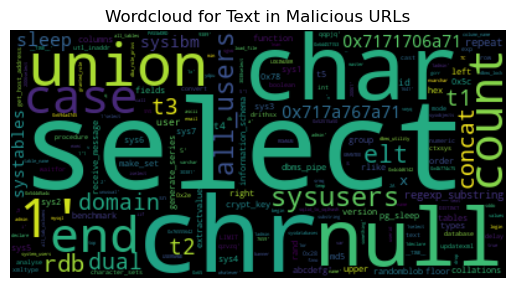

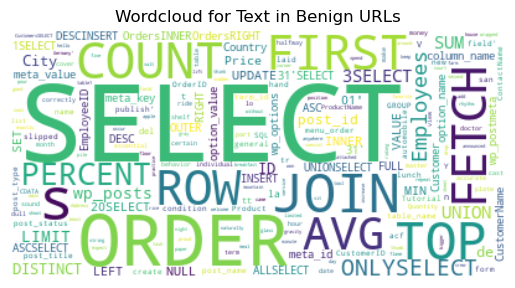

In [5]:
bad_or_good = {
    'badwords_key': 1,
    'goodwords_key': 0 
}

for name, label in bad_or_good.items():
    odf['temp'] = odf.apply(lambda r: wordcloud_generator(r, label), axis=1)
    wordcloud_ready = "".join(odf['temp'].astype(str).tolist())

    if label == 1:
        wc = WordCloud(collocations=False).generate(wordcloud_ready)

        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')  
        plt.title("Wordcloud for Text in Malicious URLs")
        plt.show()

    else:
        wc = WordCloud(collocations=False, background_color='white').generate(wordcloud_ready)
        
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')  
        plt.title("Wordcloud for Text in Benign URLs")
        plt.show()

odf = odf.drop(columns=['temp'])


### preprocessing

#### create new columns for final labels and sql queries/sentences

In [6]:
odf["new_label"] = None
odf["new_sentence"] = None

odf

,Sentence,Label,Unnamed: 2,Unnamed: 3,new_label,new_sentence
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN,None,None
1,create user name identified by pass123 tempora...,NaN,1,NaN,None,None
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN,None,None
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN,None,None
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN,None,None
...,...,...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN,None,None
30915,DELETE FROM tomorrow,0,NaN,NaN,None,None
30916,SELECT wide ( s ) FROM west,0,NaN,NaN,None,None
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN,None,None


#### getting actual labels into new label column

In [7]:
#if label isnt in 'label' column, then take from the next column. if it isnt there, take it from the next

def extract_label(row):
    for val in [row['Label'], row['Unnamed: 2'], row['Unnamed: 3']]:
        try:
            val_int = int(val)
            if val_int in [0, 1]:
                return val_int
        except (ValueError, TypeError):
            continue
    return None  

# run the extract_label function then add real labels into new column called 'new_label)
odf['new_label'] = odf.apply(extract_label, axis=1)

odf

,Sentence,Label,Unnamed: 2,Unnamed: 3,new_label,new_sentence
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN,1,None
1,create user name identified by pass123 tempora...,NaN,1,NaN,1,None
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN,1,None
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN,1,None
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN,1,None
...,...,...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN,0,None
30915,DELETE FROM tomorrow,0,NaN,NaN,0,None
30916,SELECT wide ( s ) FROM west,0,NaN,NaN,0,None
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN,0,None


#### getting some missing sentences from other columns into new sentence column

In [8]:
#if in 'Sentence' column is empty, take the sentence that was wrongly mispplaced in 'Label' column
def get_correct_sentence(row):
    if pd.isna(row['Sentence']) or row['Sentence'] == '': 
        for value in row['Label']:
            if isinstance(value, str) and value.strip():
                return value
        return None  
    else:
        return row['Sentence']

odf['new_sentence'] = odf.apply(get_correct_sentence, axis=1)

odf


,Sentence,Label,Unnamed: 2,Unnamed: 3,new_label,new_sentence
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN,1,""" or pg_sleep ( __TIME__ ) --"
1,create user name identified by pass123 tempora...,NaN,1,NaN,1,create user name identified by pass123 tempora...
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN,1,AND 1 = utl_inaddr.get_host_address ( ...
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN,1,select * from users where id = '1' or @ @1 ...
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN,1,"select * from users where id = 1 or 1#"" ( ..."
...,...,...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN,0,DELETE FROM door WHERE grow = 'small'
30915,DELETE FROM tomorrow,0,NaN,NaN,0,DELETE FROM tomorrow
30916,SELECT wide ( s ) FROM west,0,NaN,NaN,0,SELECT wide ( s ) FROM west
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN,0,SELECT * FROM ( SELECT slide FROM breath )


#### getting rid of sql statements without whitespaces (junk words like 'like', 'e', etc.)

In [9]:
odf = odf[odf['new_sentence'].str.contains(r'\s')] # remove values without whitespace

odf

,Sentence,Label,Unnamed: 2,Unnamed: 3,new_label,new_sentence
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN,1,""" or pg_sleep ( __TIME__ ) --"
1,create user name identified by pass123 tempora...,NaN,1,NaN,1,create user name identified by pass123 tempora...
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN,1,AND 1 = utl_inaddr.get_host_address ( ...
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN,1,select * from users where id = '1' or @ @1 ...
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN,1,"select * from users where id = 1 or 1#"" ( ..."
...,...,...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN,0,DELETE FROM door WHERE grow = 'small'
30915,DELETE FROM tomorrow,0,NaN,NaN,0,DELETE FROM tomorrow
30916,SELECT wide ( s ) FROM west,0,NaN,NaN,0,SELECT wide ( s ) FROM west
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN,0,SELECT * FROM ( SELECT slide FROM breath )


In [10]:
odf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24475 entries, 0 to 30918
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sentence      24475 non-null  object 
 1   Label         24221 non-null  object 
 2   Unnamed: 2    287 non-null    object 
 3   Unnamed: 3    8 non-null      float64
 4   new_label     24475 non-null  int64  
 5   new_sentence  24475 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.3+ MB


#### get rid of old columns

In [11]:
odf = odf.drop(columns=['Sentence','Label', 'Unnamed: 2', 'Unnamed: 3'])

odf

,new_label,new_sentence
0,1,""" or pg_sleep ( __TIME__ ) --"
1,1,create user name identified by pass123 tempora...
2,1,AND 1 = utl_inaddr.get_host_address ( ...
3,1,select * from users where id = '1' or @ @1 ...
4,1,"select * from users where id = 1 or 1#"" ( ..."
...,...,...
30914,0,DELETE FROM door WHERE grow = 'small'
30915,0,DELETE FROM tomorrow
30916,0,SELECT wide ( s ) FROM west
30917,0,SELECT * FROM ( SELECT slide FROM breath )


#### drop null values so that all columns have same no. of rows

In [12]:
odf = odf.dropna()

odf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24475 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   new_label     24475 non-null  int64 
 1   new_sentence  24475 non-null  object
dtypes: int64(1), object(1)
memory usage: 573.6+ KB


### modeling

#### train-test split

In [13]:
X = odf['new_sentence']
y = odf['new_label']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### tfidf + logistic regression

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib

token_pattern = r"(?u)\b\w+\b|[^\w\s]"

lr_tfidf_pipeline = make_pipeline(
    TfidfVectorizer(ngram_range=(1,3), max_features= 10000, token_pattern=token_pattern),
    LogisticRegression(max_iter=1000)
)

lr_tfidf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidfvectorizer',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 3),
                                 token_pattern='(?u)\\b\\w+\\b|[^\\w\\s]')),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [16]:
joblib.dump(lr_tfidf_pipeline, "lr_tfidf.pkl")

['lr_tfidf.pkl']

In [17]:
from sklearn.metrics import classification_report

y_pred_lr_tfidf = lr_tfidf_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_lr_tfidf, digits=4))

              precision    recall  f1-score   support

           0     0.9973    0.9981    0.9977      2607
           1     0.9978    0.9969    0.9974      2288

    accuracy                         0.9975      4895
   macro avg     0.9976    0.9975    0.9975      4895
weighted avg     0.9975    0.9975    0.9975      4895



#### count vectorizer + logistic regression

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

lr_cv_pipeline = make_pipeline(
    CountVectorizer(token_pattern=token_pattern, max_features=10000, ngram_range=(1,3)),
    LogisticRegression(max_iter=1000)
)

lr_cv_pipeline.fit(X_train,y_train)

Pipeline(steps=[('countvectorizer',
                 CountVectorizer(max_features=10000, ngram_range=(1, 3),
                                 token_pattern='(?u)\\b\\w+\\b|[^\\w\\s]')),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [19]:
y_pred_lr_countvec = lr_cv_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_lr_countvec, digits=4))

              precision    recall  f1-score   support

           0     0.9966    0.9981    0.9973      2607
           1     0.9978    0.9961    0.9969      2288

    accuracy                         0.9971      4895
   macro avg     0.9972    0.9971    0.9971      4895
weighted avg     0.9971    0.9971    0.9971      4895



#### tfidf + naive bayes

In [20]:
from sklearn.naive_bayes import MultinomialNB

nb_tfidf_pipeline = make_pipeline(
    TfidfVectorizer(ngram_range=(1,3), max_features=10000, token_pattern=token_pattern),
    MultinomialNB()
)

nb_tfidf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidfvectorizer',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 3),
                                 token_pattern='(?u)\\b\\w+\\b|[^\\w\\s]')),
                ('multinomialnb', MultinomialNB())])

In [21]:
y_pred_nb_tfidf = nb_tfidf_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_nb_tfidf, digits=4))

              precision    recall  f1-score   support

           0     0.9969    0.9946    0.9958      2607
           1     0.9939    0.9965    0.9952      2288

    accuracy                         0.9955      4895
   macro avg     0.9954    0.9956    0.9955      4895
weighted avg     0.9955    0.9955    0.9955      4895



#### count vectorizer + naive bayes

In [22]:
nb_cv_pipeline = make_pipeline(
    CountVectorizer(token_pattern=token_pattern, max_features=10000, ngram_range=(1,3)),
    MultinomialNB()
)

nb_cv_pipeline.fit(X_train,y_train)

Pipeline(steps=[('countvectorizer',
                 CountVectorizer(max_features=10000, ngram_range=(1, 3),
                                 token_pattern='(?u)\\b\\w+\\b|[^\\w\\s]')),
                ('multinomialnb', MultinomialNB())])

In [23]:
y_pred_nb_countvec = nb_cv_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_nb_countvec, digits=4))

              precision    recall  f1-score   support

           0     0.9946    0.9919    0.9933      2607
           1     0.9908    0.9939    0.9924      2288

    accuracy                         0.9928      4895
   macro avg     0.9927    0.9929    0.9928      4895
weighted avg     0.9929    0.9928    0.9929      4895



### model testing

In [38]:
import urllib.parse

final_model = joblib.load("lr_tfidf.pkl")

def url_splitter(url):
    parsed = urllib.parse.urlsplit(url)
    extracted = parsed.path + parsed.query + parsed.fragment
    prediction = final_model.predict([extracted])[0]
    final_prediction = "Malicious" if prediction==1 else "Benign"

    return(url, extracted, final_prediction)

In [27]:
sample_url = "https://vulnerable.example.com/search.php?q=' UNION SELECT username, password FROM users--"

print(url_splitter(sample_url))

{'url': "https://vulnerable.example.com/search.php?q=' UNION SELECT username, password FROM users--", 'extracted': "/search.phpq=' UNION SELECT username, password FROM users--", 'prediction': 'Malicious'}


In [40]:
import gradio as gr

def greet(name, intensity):
    return "Hello, " + name + "!" * int(intensity)

demo = gr.Interface(
    fn=url_splitter,
    inputs=["text"],
    outputs=["text","text","text"],
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7867
* Running on public URL: https://b081d1e8fc919e51ad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
